# DMO[1-4] -> Fatigue[4] (weekly)
This will take all 4 visits for each patient and concat them together so that it only predicts the final value

In [33]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.core.enums import MileStone, DataFrequency, PatientDataType
from src.evaluation import Evaluation
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from src.core.data_transforms import Transform
from src.model import DMORandomForestRegressor

import numpy as np
import torch
import shap

In [34]:
K_FOLDS = 5
N_VISITS = 4

In [35]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [36]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [37]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [38]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [39]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [40]:
print(dmo_data.shape)

torch.Size([428, 4, 7, 25])


In [41]:
dmo_data = dmo_data.mean(axis=2)

In [42]:
# Min max normalise the labels globally

label_normaliser = Normaliser(MinMaxScaler())
dmo_labels = label_normaliser.scaler_fit_transform(dmo_labels)

In [43]:
# shuffle
patients, *other = dmo_data.shape
generator = torch.Generator()
generator.manual_seed(1234)
random_permutation = torch.randperm(patients, generator=generator)

dmo_data = dmo_data[random_permutation]
dmo_labels = dmo_labels[random_permutation]

In [44]:
dmo_data_split = torch.tensor_split(dmo_data, K_FOLDS)
dmo_label_split = torch.tensor_split(dmo_labels, K_FOLDS)

prediction_arr = []
actual_arr = []
shap_values = []
test_inputs = []
baseline_values = []

for split_i in range(K_FOLDS):
    test_label = dmo_label_split[split_i]
    test_data = dmo_data_split[split_i]

    train_label = torch.cat(
        [dmo_label_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    train_data = torch.cat(
        [dmo_data_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    
    test_data = test_data.flatten(start_dim=1, end_dim=2)
    test_label = test_label.flatten(start_dim=1, end_dim=2)[:, -1]
    
    train_data = train_data.flatten(start_dim=1, end_dim=2)
    train_label = train_label.flatten(start_dim=1, end_dim=2)[:, -1]
    
    # normalise data
    scaler = StandardScaler()
    scaler.fit(train_data)
    
    train_data = scaler.transform(train_data)
    test_data = scaler.transform(test_data)
    
    rf_model = DMORandomForestRegressor(n_trees=500)

    rf_model.train(train_data, train_label)
    score = rf_model.score(test_data, test_label)
    print(score)
    
    prediction = torch.tensor(rf_model.predict(test_data))
    prediction = label_normaliser.scaler_inverse_labels(prediction)
    
    actual = label_normaliser.scaler_inverse_labels(test_label)
    
    prediction_arr.append(prediction)
    actual_arr.append(actual)
    
    sklearn_rf_model = rf_model.random_forest
    
    test_input_numpy = test_data
    explainer = shap.TreeExplainer(sklearn_rf_model)
    shap_value = explainer.shap_values(test_input_numpy)
    shap_values.append(shap_value)
    test_inputs.append(test_data)
    baseline_values.append(explainer.expected_value)
    

0.1877339764125341
0.14958045194548286
0.2278926748544221
0.1413955841042649
0.07919378145682898


In [46]:
prediction = torch.cat(prediction_arr)
actual = torch.cat(actual_arr)

In [47]:
prediction

tensor([25.6340, 21.9380, 20.7000, 25.4240, 17.2420, 15.6840, 18.1940, 22.9680,
        20.0640, 11.3260, 20.6280, 18.3460, 23.6740, 23.9600, 24.0220, 20.5480,
        19.9340, 19.9940, 17.7160, 21.5940, 21.5820, 20.9520, 14.8000, 18.7700,
        23.7620, 24.1420, 20.9300, 21.4740, 25.2460, 21.3660, 21.0060, 20.2100,
        24.0140, 16.2200, 13.0560, 20.7840, 14.4400, 25.4640, 23.8440, 24.0940,
        19.8480, 22.6880, 17.8140, 23.0300, 16.4640, 11.9980, 15.1060, 23.6900,
        24.4580, 19.1360, 21.4920, 23.0440, 19.9720, 23.5460, 18.7940, 21.3880,
        19.7280, 24.1280, 18.7600, 22.8660, 15.9740, 24.4180, 25.9940, 16.5800,
        21.0200, 18.0620, 21.3660, 23.3420, 11.5020, 19.2900, 12.8440, 16.3760,
        14.6660, 18.9920, 22.6680, 20.1920, 23.0680, 26.8500, 21.7680, 18.2940,
        22.2560, 21.7060, 22.8440, 16.8400, 17.5780, 21.8480, 15.3780, 22.7000,
        20.6280, 21.8340, 25.1860, 19.1700, 21.6120, 24.0300, 23.1560, 24.2500,
        13.3420, 19.3380, 21.6840, 22.03

{'accuracy': 0.016355140186915886, 'Mean Squared Error': 59.2564582824707, 'Mean Absolute Error': 6.203125953674316, 'R^2': 0.16272623247469908}


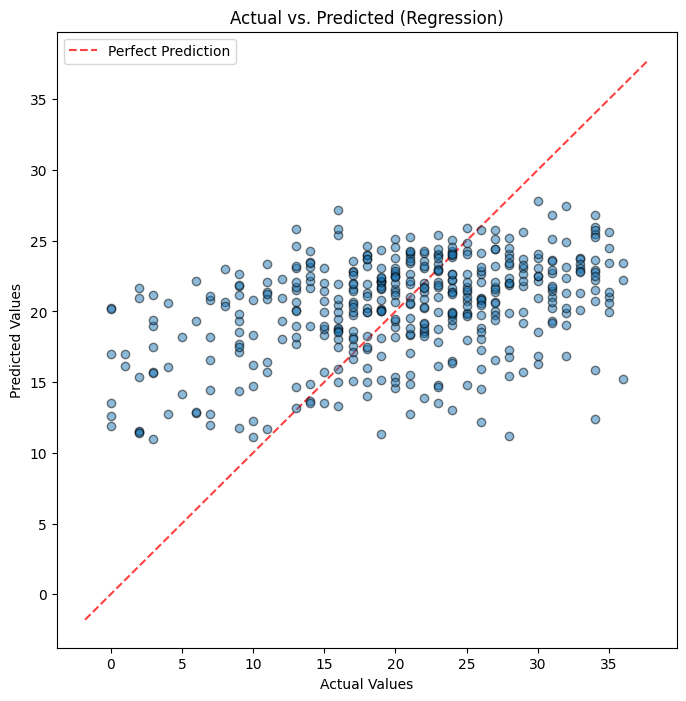

In [48]:
evaluation = Evaluation(prediction, actual)
print(evaluation.compute_all_metrics())
evaluation.evaluation_plot().show()

In [ ]:
shap_values = np.concat(xvregressor.shap_values, axis=0)
test_inputs = np.concat(xvregressor.test_inputs, axis=0)
baseline_labels = np.mean(xvregressor.baseline_values)

In [ ]:
dmo_data.shape

torch.Size([428, 4, 24])

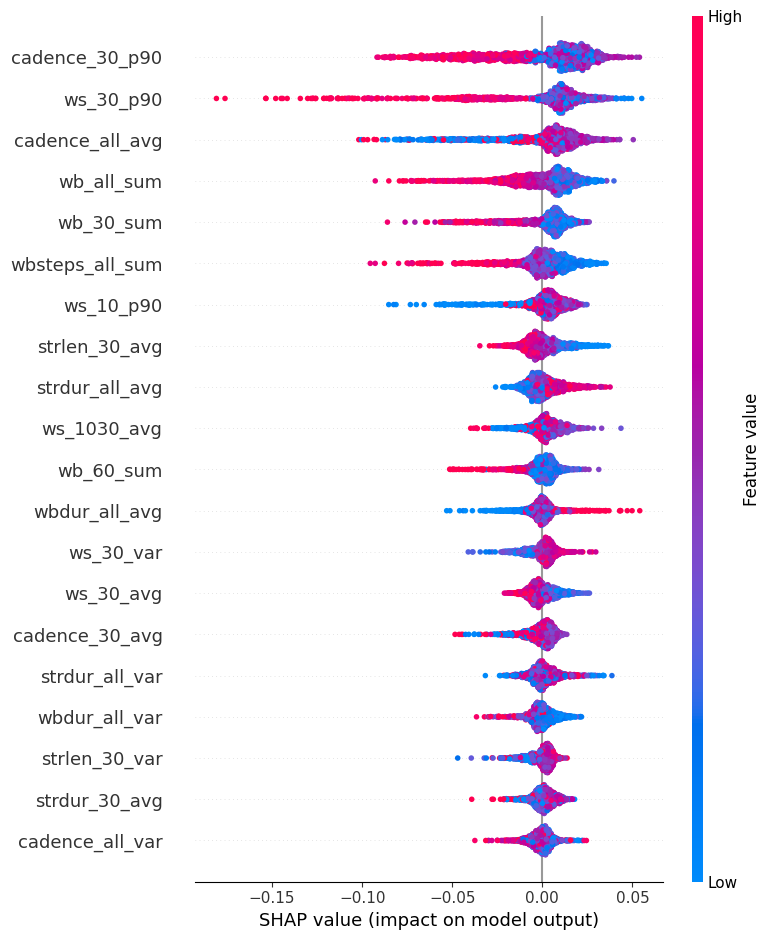

In [ ]:
import shap

#dmo_features = dmo_features + static_features

shap.summary_plot(
    shap_values,
    test_inputs,
    feature_names=dmo_features,
)

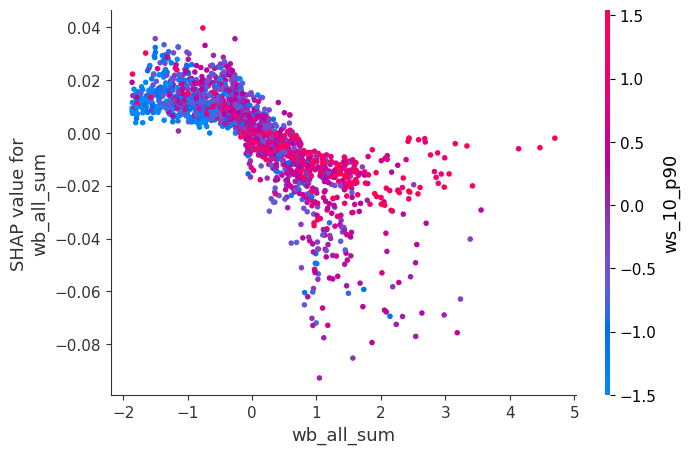

In [ ]:
shap.dependence_plot(
    "wb_all_sum", 
    shap_values, 
    test_inputs, 
    feature_names=dmo_features
)

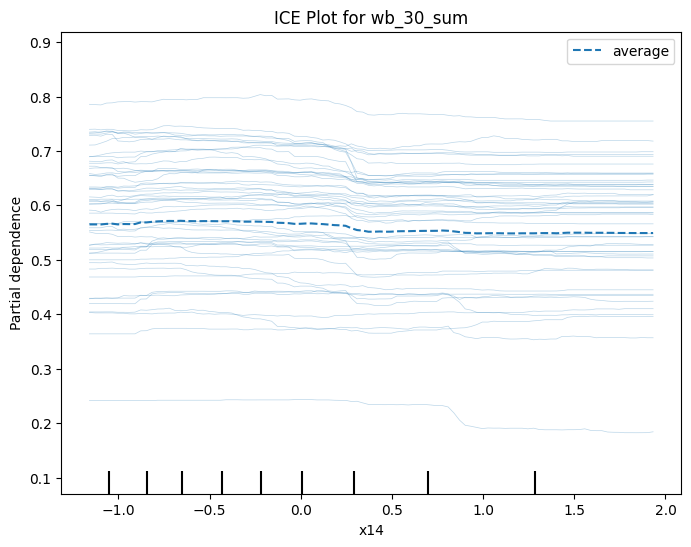

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

feature_index = dmo_features.index("wb_30_sum")

# test_numpy = test_input.numpy()

fig, ax = plt.subplots(figsize=(8, 6))

display = PartialDependenceDisplay.from_estimator(
    xvregressor.rf_model.random_forest, 
    test_inputs, 
    features=[feature_index],
    #feature_names=dmo_features,
    kind='both', 
    subsample=50,
    ax=ax
)

ax.set_title(f"ICE Plot for {dmo_features[feature_index]}")
plt.show()

In [ ]:
# # filter out less fatigued patients to see correlation

# mask = (test_label >= 0.7)
# test_numpy_filtered = test_numpy[mask]
# fig, ax = plt.subplots(figsize=(8, 6))

# display = PartialDependenceDisplay.from_estimator(
#     random_forest_model, 
#     test_numpy_filtered, 
#     features=[feature_index],
#     feature_names=dmo_features,
#     kind='both', 
#     subsample=50,
#     ax=ax
# )

# ax.set_title(f"ICE Plot for {dmo_features[feature_index]}")
# plt.show()

NameError: name 'test_label' is not defined

In [ ]:
index = 1
shap.initjs()

shap.force_plot(
    baseline_labels,             
    shap_values[index],
    test_inputs[index],
    feature_names=dmo_features,
)

NameError: name 'shap' is not defined